In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [5]:
print("Monthly Charges")

print("Mean :", df["MonthlyCharges"].mean())
print("Median :", df["MonthlyCharges"].median())
print("Mode :", df["MonthlyCharges"].mode()[0])

Monthly Charges
Mean : 64.76169246059918
Median : 70.35
Mode : 20.05


In [6]:
print("Variance :", df["MonthlyCharges"].var())

print("Standard Deviation :", df["MonthlyCharges"].std())

Variance : 905.4109343405128
Standard Deviation : 30.09004709767854


In [7]:
print("Skewness")

print(df["MonthlyCharges"].skew())

Skewness
-0.22052443394398033


In [8]:
print("Kurtosis")

print(df["MonthlyCharges"].kurt())

Kurtosis
-1.2572596945495056


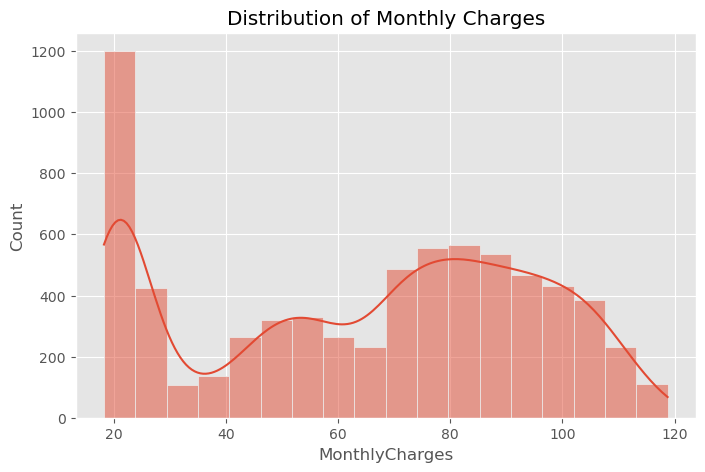

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], kde=True)

plt.title("Distribution of Monthly Charges")

plt.show()

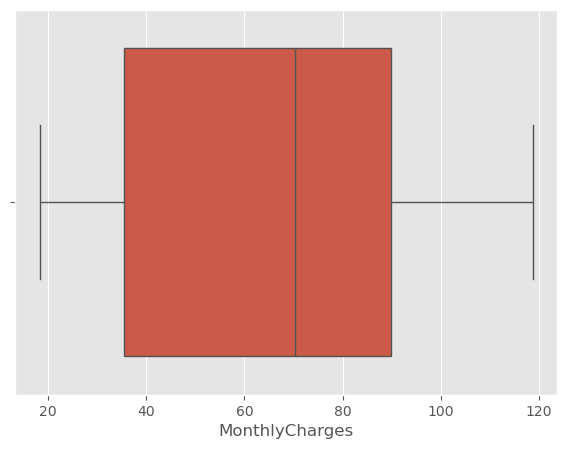

In [10]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df["MonthlyCharges"])

plt.show()

In [11]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102652
tenure,0.016567,1.000000,0.247900,0.825464
MonthlyCharges,0.220173,0.247900,1.000000,0.650864
TotalCharges,0.102652,0.825464,0.650864,1.000000


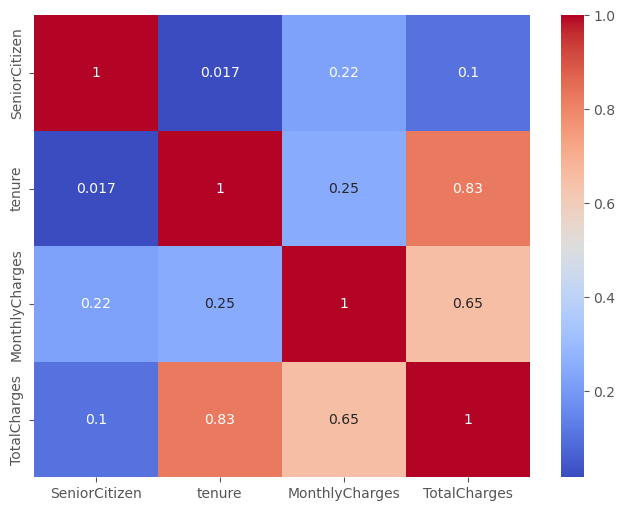

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [13]:
mean = df["MonthlyCharges"].mean()

std = df["MonthlyCharges"].std()

n = len(df)

margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin

upper = mean + margin

print("95% Confidence Interval")

print(lower, upper)

95% Confidence Interval
64.05894368975503 65.46444123144333


In [14]:
churn_yes = df[df["Churn"]=="Yes"]["MonthlyCharges"]

churn_no = df[df["Churn"]=="No"]["MonthlyCharges"]

In [15]:
t_stat, p_value = stats.ttest_ind(
    churn_yes,
    churn_no
)

print("T Statistic :", t_stat)

print("P Value :", p_value)

T Statistic : 16.536738015936308
P Value : 2.7066456068884154e-60


In [16]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Monthly Charges significantly affect churn.")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
Monthly Charges significantly affect churn.


In [17]:
table = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [18]:
chi2,p,dof,expected = stats.chi2_contingency(table)

print("Chi Square :", chi2)

print("P Value :", p)

Chi Square : 1184.5965720837926
P Value : 5.863038300673391e-258


In [19]:
chi2,p,dof,expected = stats.chi2_contingency(table)

print("Chi Square :", chi2)

print("P Value :", p)

Chi Square : 1184.5965720837926
P Value : 5.863038300673391e-258


In [20]:
if p < 0.05:
    print("Contract Type significantly influences Churn")
else:
    print("No significant relationship")

Contract Type significantly influences Churn


In [21]:
corr = df["MonthlyCharges"].corr(df["TotalCharges"])

print(corr)

0.6508643497230396


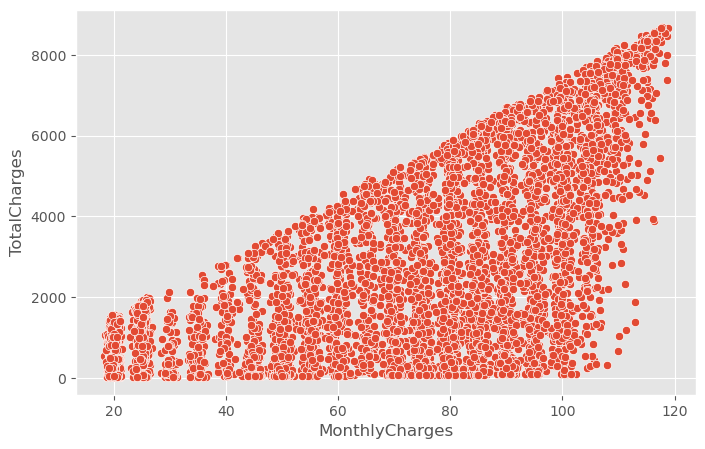

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges"
)

plt.show()

In [24]:
df.groupby("Contract")["MonthlyCharges"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,mean,median,std,min,max
Contract,,,,,
Month-to-month,66.398490,73.25,26.926599,18.75,117.45
One year,65.048608,68.75,31.840539,18.25,118.60
Two year,60.770413,64.35,34.678865,18.40,118.75


In [25]:
prob = (
    df["Churn"]
    .value_counts(normalize=True)
)

print(prob)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [27]:
print("""
Business Recommendations

1. Focus on month-to-month customers.

2. Reduce churn among high-paying customers.

3. Offer discounts for long-term contracts.

4. Improve customer support.

5. Encourage annual subscriptions.
""")


Business Recommendations

1. Focus on month-to-month customers.

2. Reduce churn among high-paying customers.

3. Offer discounts for long-term contracts.

4. Improve customer support.

5. Encourage annual subscriptions.



In [28]:
print("""
Conclusion

Statistical analysis confirmed that
Monthly Charges and Contract Type
have a significant impact on customer churn.

These findings provide strong evidence
for designing targeted customer retention strategies.
""")


Conclusion

Statistical analysis confirmed that
Monthly Charges and Contract Type
have a significant impact on customer churn.

These findings provide strong evidence
for designing targeted customer retention strategies.

